# Maestría en Ciencias de la Computación - Visión Computacional

Fecha de entrega: domingo 26 de abril de 2026

Alumno: Jesús Virgilio Ayala Gaspar 

Profesor: Arturo Espinosa Romero

---

## ADA 03 - Detección de Esquinas

Utilizando las transformada de Hough que vimos en clase, así como cualquier otro metodo de los vistos hasta ahora que ustedes consideren necesario, implemente un programa que encuentre las coordenadas de las esquinas que se muestran en las reticula contenidas en las imágenes.

---

## Procedimiento

El procedimiento para desarrollar el programa de Detección de Esquinas es el siguiente:

- 1. Detección de bordes
- 2. Transformada de Hough
- 3. Clasificar líneas
- 4. Calcular intersecciones
- 5. Eliminar duplicados

---

### 1. Detección de bordes


Suavizamos la imágen mediante la función GaussianBlur() de OpenCV, esto aplica un filtro Gaussiano y prepara la imágen para detectar sus bordes:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Leer imágen 
img = cv2.imread("Reticulas/Reticula_0.png")

#Procesar imágen
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

Una vez procesada la imágen utilizaremos la función Canny() que se encarga de:

- Calcular gradientes 
- Detectar dónde hay cambios fuertes (bordes)
- Aplica umbrales (para decidir qué es borde real)

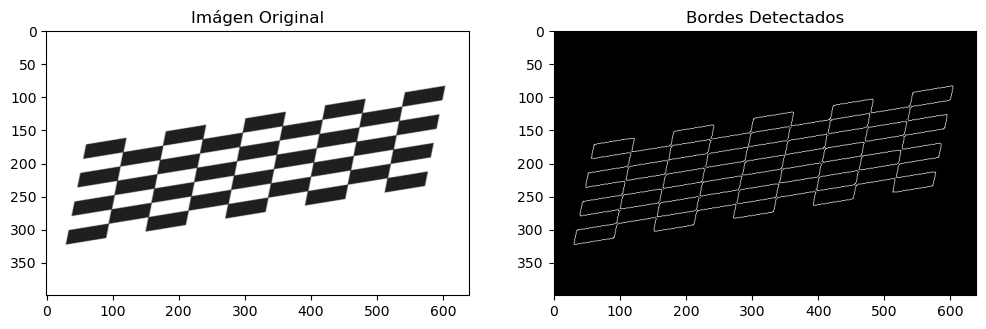

In [2]:
#Deteccion de Bordes
edges = cv2.Canny(blur, 150, 200)

#Plot Examples
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imágen Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.title("Bordes Detectados")

plt.show()

---

### 2. Transformada de Hough

La Transformada de Hough se encarga de convertir pixeles sueltos (bordes detectados) en una lista de líneas mediante las coordenadas de inicio y fin de cada línea:

In [3]:
lines = cv2.HoughLinesP(
    edges,
    1,              # resolución en píxeles
    np.pi/180,      # resolución angular
    threshold=10,  # mínimo de votos
    minLineLength=10,
    maxLineGap=10
)

#print(lines)

Y podemos ver como sería la imágen de estas líneas:

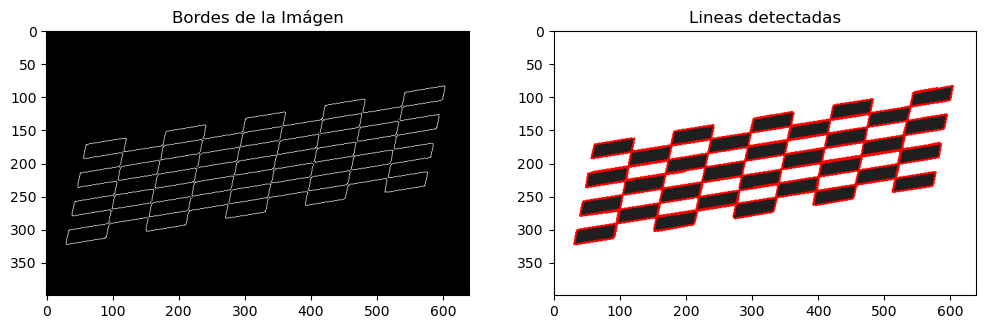

In [4]:
imgLines = img.copy()

for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(imgLines, (x1,y1), (x2,y2), (0,0,255), 2)

plt.figure(figsize=(12, 4))
    
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.title("Bordes de la Imágen")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(imgLines, cv2.COLOR_BGR2RGB))
plt.title("Lineas detectadas")

plt.show()

---

### 3. Clasificar Líneas

Como las esquinas se generan de la intersección entre dos familias de líneas distintas clasificaremos las líneas por pendiente positiva o negativa según su ángulo:

In [5]:
linesPositive = []
linesNegative = []

for line in lines:
    x1, y1, x2, y2 = line[0]

    #Calculamos el ángulo
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))

    #Caso de línea horizontal
    if angle < 0:
        angle += 180

    # separación simple
    if angle < 110:
        linesPositive.append((x1,y1,x2,y2))
    else:
        linesNegative.append((x1,y1,x2,y2))

A continuación la visualización de la clasificacioń de las líneas:

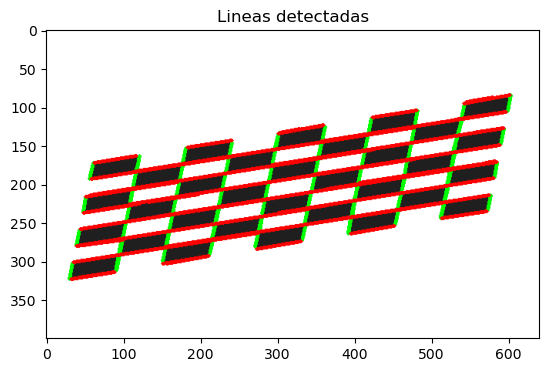

In [6]:
imgTest = img.copy()

# positivas → verde
for x1,y1,x2,y2 in linesPositive:
    cv2.line(imgTest, (x1,y1), (x2,y2), (0,255,0), 3)

# negativas → rojo
for x1,y1,x2,y2 in linesNegative:
    cv2.line(imgTest, (x1,y1), (x2,y2), (0,0,255), 3)

plt.figure(figsize=(12, 4))
    
#Aún no sé utilizar plt.plot correctamente
plt.subplot(1,1,1)
plt.imshow(cv2.cvtColor(imgTest, cv2.COLOR_BGR2RGB))
plt.title("Lineas detectadas")

plt.show()

---

### 4. Calcular Intersecciones

Con todo lo anterior preparado llegamos al apartado donde detectamos las esquinas en la imágen

Para ello definimos la función intersect() con el siguiente algoritmo:

- le pasamos dos líneas como parámetro
- Planteamos el sistema de ecuacione y resolvemos mediante Cramer
- Comprobamos si son líneas paralelas
- En caso contrario calculamos las coordenadas de intersección
- Por último retornamos las coordenadas

In [7]:
def intersect(l1, l2):
    x1,y1,x2,y2 = l1
    x3,y3,x4,y4 = l2

    # Representación Ax + By = C
    A1 = y2 - y1
    B1 = x1 - x2
    C1 = A1*x1 + B1*y1

    A2 = y4 - y3
    B2 = x3 - x4
    C2 = A2*x3 + B2*y3

    det = A1*B2 - A2*B1

    # Si det = 0 → líneas paralelas
    if abs(det) < 1e-6:
        return None

    x = (B2*C1 - B1*C2) / det
    y = (A1*C2 - A2*C1) / det

    return int(x), int(y)

Una vez definido el método para calcular intersecciones almacenaremos cada intersección en el arreglo corners 

In [8]:
corners = []

for l1 in linesPositive:
    for l2 in linesNegative:
        pt = intersect(l1, l2)

        if pt is not None:
            x, y = pt

            # filtro básico: dentro de la imagen
            if 0 <= x < img.shape[1] and 0 <= y < img.shape[0]:
                corners.append((x,y))

A continuación, la visualización de las esquinas:

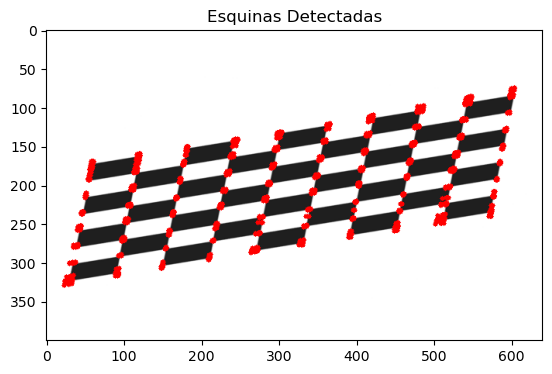

In [9]:
imgCorners = img.copy()

for x,y in corners:
    cv2.circle(imgCorners, (x,y), 3, (0,0,255), -1)

plt.subplot(1,1,1)
plt.imshow(cv2.cvtColor(imgCorners, cv2.COLOR_BGR2RGB))
plt.title("Esquinas Detectadas")

plt.show()

---

### 5. Eliminar Duplicados

El paso final de la tarea consiste en eliminar duplicados y limpiar el ruido de las esquinas detectadas

Primero utilizaremos una técnica de clustering que agrupará los puntos encontrados en las esquinas correspondientes 

Para ello, definimos la funcion clusterPoints() con las siguientes características:

- Le pasamos una lista de puntos como parámetro y definimos un threshold para filtrar por distancia
- Iteramos sobre la lista de puntos
- Si un punto está cerca de otro los junta en un grupo
- Si un punto no está cerca de otro entonces crea un nuevo grupo

In [10]:
def clusterPoints(points, distThresh):
    clusters = []

    for p in points:
        p = np.array(p)

        found = False
        for i, c in enumerate(clusters):
            if np.linalg.norm(p - c) < distThresh:
                # actualizar centro (promedio)
                clusters[i] = (c + p) / 2
                found = True
                break

        if not found:
            clusters.append(p)

    return [tuple(map(int, c)) for c in clusters]

Por último, creamos una variable para las nuevas esquinas filtradas y graficamos el resultado final

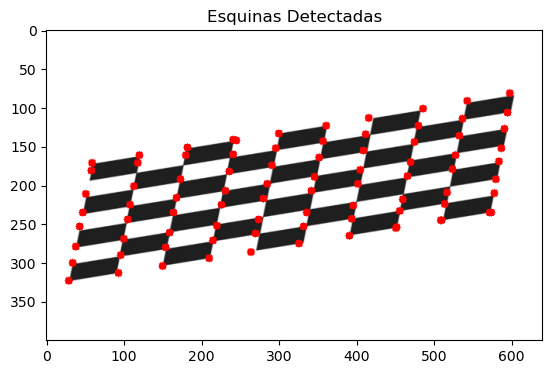

In [11]:
cornersClean = clusterPoints(corners, distThresh=15)

imgFinal = img.copy()

for x,y in cornersClean:
    cv2.circle(imgFinal, (x,y), 5, (0,0,255), -1)

plt.subplot(1,1,1)
plt.imshow(cv2.cvtColor(imgFinal, cv2.COLOR_BGR2RGB))
plt.title("Esquinas Detectadas")

plt.show()

"En caso de encontrar errores ajustar los parámetros de las funciones"